In [2]:
import pandas as pd, glob, json
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Streaming_History_Audio_2026.json to Streaming_History_Audio_2026.json
Saving Streaming_History_Audio_2025_1.json to Streaming_History_Audio_2025_1.json
Saving Streaming_History_Audio_2025.json to Streaming_History_Audio_2025.json
Saving Streaming_History_Audio_2024_1.json to Streaming_History_Audio_2024_1.json
Saving Streaming_History_Audio_2024.json to Streaming_History_Audio_2024.json
Saving Streaming_History_Audio_2023.json to Streaming_History_Audio_2023.json
Saving Streaming_History_Audio_2022.json to Streaming_History_Audio_2022.json
Saving Streaming_History_Audio_2021.json to Streaming_History_Audio_2021.json
Saving Streaming_History_Audio_2020.json to Streaming_History_Audio_2020.json
Saving Streaming_History_Audio_2019.json to Streaming_History_Audio_2019.json


In [4]:
files = glob.glob('*.json')

In [5]:
df = pd.concat([pd.read_json(f) for f in files])

In [6]:
df.head(10)

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2024-08-03T20:28:08Z,osx,158536,CA,174.95.239.190,People Watching,Conan Gray,Superache,spotify:track:3TFoEJe5zNuHZStRboWPxg,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722717e+09,False
1,2024-08-03T20:30:52Z,osx,163648,CA,174.95.239.190,Nonsense,Sabrina Carpenter,emails i can't send,spotify:track:6dgUya35uo964z7GZXM07g,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722717e+09,False
2,2024-08-03T20:34:21Z,osx,207120,CA,174.95.239.190,she's all i wanna be,Tate McRae,i used to think i could fly,spotify:track:7l9IqDtVWJurTvkQHq1BGh,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722717e+09,False
3,2024-08-03T20:38:01Z,osx,219813,CA,174.95.239.190,Someone to You,BANNERS,Where the Shadow Ends,spotify:track:2amiYVWBp4ixa2Ja7ix5cx,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722717e+09,False
4,2024-08-03T20:39:05Z,osx,63660,CA,174.95.239.190,Lost on You,LP,Lost On You,spotify:track:40x5K8xyIWVmSeUrYjj0os,None,...,NaN,NaN,NaN,trackdone,fwdbtn,False,True,False,1.722717e+09,False
5,2024-08-03T20:43:26Z,osx,260773,CA,174.95.239.190,Bad Liar,Imagine Dragons,Origins,spotify:track:2RSHsoi04658QL5xgQVov3,None,...,NaN,NaN,NaN,fwdbtn,trackdone,False,False,False,1.722718e+09,False
6,2024-08-03T20:46:48Z,osx,202000,CA,174.95.239.190,Where's My Love,SYML,SYML,spotify:track:1B62o4CbdL9ckGvwsz2cgn,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722718e+09,False
7,2024-08-03T20:49:11Z,osx,141805,CA,174.95.239.190,STAY (with Justin Bieber),The Kid LAROI,F*CK LOVE 3+: OVER YOU,spotify:track:567e29TDzLwZwfDuEpGTwo,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722718e+09,False
8,2024-08-03T20:52:15Z,osx,184453,CA,174.95.239.190,MIDDLE OF THE NIGHT,Elley Duhé,PHOENIX,spotify:track:45JYEmfoWSpCA3Paut7YXE,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722718e+09,False
9,2024-08-03T20:55:44Z,osx,207853,CA,174.95.239.190,Shivers,Ed Sheeran,=,spotify:track:50nfwKoDiSYg8zOCREWAm5,None,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1.722718e+09,False


In [7]:
print(df.shape)

(82911, 23)


In [8]:
#df = df[df['ms_played']>30000]
df['ts'] = pd.to_datetime(df['ts'], utc=True)
df['ts'] = df['ts'].dt.tz_convert('America/Toronto')
df['minutes_played'] = df['ms_played'] / 60000
df['hour'] = df['ts'].dt.hour
df['day'] = df['ts'].dt.day_name()
df['month'] = df['ts'].dt.month
df['year'] = df['ts'].dt.year
df['artist'] = df['master_metadata_album_artist_name']
df['track'] = df['master_metadata_track_name']

In [9]:
df.head(10)

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,offline,offline_timestamp,incognito_mode,minutes_played,hour,day,month,year,artist,track
0,2024-08-03 16:28:08-04:00,osx,158536,CA,174.95.239.190,People Watching,Conan Gray,Superache,spotify:track:3TFoEJe5zNuHZStRboWPxg,None,...,False,1.722717e+09,False,2.642267,16,Saturday,8,2024,Conan Gray,People Watching
1,2024-08-03 16:30:52-04:00,osx,163648,CA,174.95.239.190,Nonsense,Sabrina Carpenter,emails i can't send,spotify:track:6dgUya35uo964z7GZXM07g,None,...,False,1.722717e+09,False,2.727467,16,Saturday,8,2024,Sabrina Carpenter,Nonsense
2,2024-08-03 16:34:21-04:00,osx,207120,CA,174.95.239.190,she's all i wanna be,Tate McRae,i used to think i could fly,spotify:track:7l9IqDtVWJurTvkQHq1BGh,None,...,False,1.722717e+09,False,3.452000,16,Saturday,8,2024,Tate McRae,she's all i wanna be
3,2024-08-03 16:38:01-04:00,osx,219813,CA,174.95.239.190,Someone to You,BANNERS,Where the Shadow Ends,spotify:track:2amiYVWBp4ixa2Ja7ix5cx,None,...,False,1.722717e+09,False,3.663550,16,Saturday,8,2024,BANNERS,Someone to You
4,2024-08-03 16:39:05-04:00,osx,63660,CA,174.95.239.190,Lost on You,LP,Lost On You,spotify:track:40x5K8xyIWVmSeUrYjj0os,None,...,False,1.722717e+09,False,1.061000,16,Saturday,8,2024,LP,Lost on You
5,2024-08-03 16:43:26-04:00,osx,260773,CA,174.95.239.190,Bad Liar,Imagine Dragons,Origins,spotify:track:2RSHsoi04658QL5xgQVov3,None,...,False,1.722718e+09,False,4.346217,16,Saturday,8,2024,Imagine Dragons,Bad Liar
6,2024-08-03 16:46:48-04:00,osx,202000,CA,174.95.239.190,Where's My Love,SYML,SYML,spotify:track:1B62o4CbdL9ckGvwsz2cgn,None,...,False,1.722718e+09,False,3.366667,16,Saturday,8,2024,SYML,Where's My Love
7,2024-08-03 16:49:11-04:00,osx,141805,CA,174.95.239.190,STAY (with Justin Bieber),The Kid LAROI,F*CK LOVE 3+: OVER YOU,spotify:track:567e29TDzLwZwfDuEpGTwo,None,...,False,1.722718e+09,False,2.363417,16,Saturday,8,2024,The Kid LAROI,STAY (with Justin Bieber)
8,2024-08-03 16:52:15-04:00,osx,184453,CA,174.95.239.190,MIDDLE OF THE NIGHT,Elley Duhé,PHOENIX,spotify:track:45JYEmfoWSpCA3Paut7YXE,None,...,False,1.722718e+09,False,3.074217,16,Saturday,8,2024,Elley Duhé,MIDDLE OF THE NIGHT
9,2024-08-03 16:55:44-04:00,osx,207853,CA,174.95.239.190,Shivers,Ed Sheeran,=,spotify:track:50nfwKoDiSYg8zOCREWAm5,None,...,False,1.722718e+09,False,3.464217,16,Saturday,8,2024,Ed Sheeran,Shivers


In [10]:
df.isna().sum()

,0
ts,0
platform,0
ms_played,0
conn_country,0
ip_addr,0
master_metadata_track_name,63
master_metadata_album_artist_name,63
master_metadata_album_album_name,63
spotify_track_uri,63
episode_name,82848


In [11]:
df = df.drop(columns=['master_metadata_track_name','master_metadata_album_artist_name','episode_name', 'episode_show_name', 'spotify_episode_uri','audiobook_title','audiobook_uri','audiobook_chapter_uri','audiobook_chapter_title','offline_timestamp'])

In [12]:
df

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_album_album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,incognito_mode,minutes_played,hour,day,month,year,artist,track
0,2024-08-03 16:28:08-04:00,osx,158536,CA,174.95.239.190,Superache,spotify:track:3TFoEJe5zNuHZStRboWPxg,trackdone,trackdone,False,False,False,False,2.642267,16,Saturday,8,2024,Conan Gray,People Watching
1,2024-08-03 16:30:52-04:00,osx,163648,CA,174.95.239.190,emails i can't send,spotify:track:6dgUya35uo964z7GZXM07g,trackdone,trackdone,False,False,False,False,2.727467,16,Saturday,8,2024,Sabrina Carpenter,Nonsense
2,2024-08-03 16:34:21-04:00,osx,207120,CA,174.95.239.190,i used to think i could fly,spotify:track:7l9IqDtVWJurTvkQHq1BGh,trackdone,trackdone,False,False,False,False,3.452000,16,Saturday,8,2024,Tate McRae,she's all i wanna be
3,2024-08-03 16:38:01-04:00,osx,219813,CA,174.95.239.190,Where the Shadow Ends,spotify:track:2amiYVWBp4ixa2Ja7ix5cx,trackdone,trackdone,False,False,False,False,3.663550,16,Saturday,8,2024,BANNERS,Someone to You
4,2024-08-03 16:39:05-04:00,osx,63660,CA,174.95.239.190,Lost On You,spotify:track:40x5K8xyIWVmSeUrYjj0os,trackdone,fwdbtn,False,True,False,False,1.061000,16,Saturday,8,2024,LP,Lost on You
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,2023-12-31 15:09:08-05:00,cast,232947,CA,174.89.221.156,"O Maahi (From ""Dunki"")",spotify:track:0qQ4IdhjzNr0gJhdMTf2n3,trackdone,trackdone,False,False,False,False,3.882450,15,Sunday,12,2023,Pritam,"O Maahi (From ""Dunki"")"
9997,2023-12-31 15:11:57-05:00,cast,167636,CA,174.89.221.156,"O Maahi (From ""Dunki"")",spotify:track:0qQ4IdhjzNr0gJhdMTf2n3,trackdone,fwdbtn,False,True,False,False,2.793933,15,Sunday,12,2023,Pritam,"O Maahi (From ""Dunki"")"
9998,2023-12-31 15:12:21-05:00,cast,20912,CA,174.89.221.156,"Ishq Jaisa Kuch (From ""Fighter"")",spotify:track:23YpzkTDtU78GK6vpgRbkM,fwdbtn,fwdbtn,False,True,False,False,0.348533,15,Sunday,12,2023,Vishal-Shekhar,"Ishq Jaisa Kuch (From ""Fighter"")"
9999,2023-12-31 15:13:49-05:00,cast,86203,CA,174.89.221.156,"Sher Khul Gaye (From ""Fighter"")",spotify:track:0VXBujZKMLLlmee25BXEQs,fwdbtn,endplay,False,True,False,False,1.436717,15,Sunday,12,2023,Vishal-Shekhar,"Sher Khul Gaye (From ""Fighter"")"


In [13]:
df = df.replace('None', float('nan'))
df = df.dropna(subset=['artist', 'track'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82848 entries, 0 to 10000
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype                          
---  ------                            --------------  -----                          
 0   ts                                82848 non-null  datetime64[ns, America/Toronto]
 1   platform                          82848 non-null  object                         
 2   ms_played                         82848 non-null  int64                          
 3   conn_country                      82848 non-null  object                         
 4   ip_addr                           82848 non-null  object                         
 5   master_metadata_album_album_name  82848 non-null  object                         
 6   spotify_track_uri                 82848 non-null  object                         
 7   reason_start                      82848 non-null  object                         
 8   reason_end           

In [15]:
print('Total number of plays is ', len(df))
print('Total minutes on Spotify ', round(df['minutes_played'].sum()/60),1)
print("Total unique artists are ", df['artist'].nunique())
print("Total unique tracks are ", df['track'].nunique())

Total number of plays is  82848
Total minutes on Spotify  4041 1
Total unique artists are  2715
Total unique tracks are  8483


In [16]:
top_plays = df['artist'].value_counts().head(10)
top_plays

,count
artist,
Taylor Swift,6087
Pritam,3065
Imagine Dragons,1474
Atif Aslam,1421
Vishal-Shekhar,1309
Arijit Singh,1113
One Direction,971
Ariana Grande,940
Charlie Puth,925


In [17]:
top_artist = df.groupby('artist')['minutes_played'].sum().sort_values(ascending=False).head(10)
top_artist

,minutes_played
artist,
Taylor Swift,19627.930800
Pritam,10948.281100
Atif Aslam,5139.195983
Vishal-Shekhar,4872.831750
Imagine Dragons,3923.756500
Arijit Singh,3563.458950
Katy Perry,2963.554617
A.R. Rahman,2810.750950
One Direction,2730.962217


My #1 artist by play count is **Taylor Swift** but the more interesting finding is Katy Perry. She ranks #10 by number of plays, but jumps to #7 by total minutes listened. That means when I put on Katy Perry, I stay for the whole song 'every time'.

# Central Tendency


In [18]:
print('Mean play (min):', round(df['minutes_played'].mean(),2))
print('Median play (min):', round(df['minutes_played'].median(),2))

Mean play (min): 2.93
Median play (min): 3.26


There is **left skew** in my listening habits which means that there are partial song listens which makes my average down.

In [19]:
print(df['minutes_played'].describe())

count    82848.000000
mean         2.926842
std          1.760963
min          0.000000
25%          2.133287
50%          3.259075
75%          3.876779
max         65.339733
Name: minutes_played, dtype: float64


In [20]:
print('Peak hour:', df['hour'].mode()[0])
print('Most player track:', df['track'].mode()[0])

Peak hour: 14
Most player track: Husn


In [21]:
artist_stats = df.groupby('artist').agg({
    'track': ['count'],
    'minutes_played': ['mean', 'sum']
}).reset_index().sort_values(('track', 'count'), ascending=False).head(15)
artist_stats.columns = ['artist', 'plays', 'avg_mins', 'total_mins']
print(artist_stats)

               artist  plays  avg_mins    total_mins
2311     Taylor Swift   6087  3.224566  19627.930800
1803           Pritam   3065  3.572033  10948.281100
957   Imagine Dragons   1474  2.661979   3923.756500
238        Atif Aslam   1421  3.616605   5139.195983
2489   Vishal-Shekhar   1309  3.722561   4872.831750
208      Arijit Singh   1113  3.201670   3563.458950
1706    One Direction    971  2.812525   2730.962217
206     Ariana Grande    940  2.771944   2605.626900
460      Charlie Puth    925  2.531632   2341.759350
1187       Katy Perry    922  3.214267   2963.554617
2309       Tate McRae    891  2.191041   1952.217383
1466         Maroon 5    885  3.027029   2678.920467
678        Ed Sheeran    874  2.922735   2554.470817
659          Dua Lipa    838  2.739992   2296.112983
13        A.R. Rahman    821  3.423570   2810.750950


I have played Taylor Swift 6087 times and I have listened to her songs for full 13 days of my life. Tate McRae has 891 plays, but the average minutes for her songs is lowest indicating I tend to rarely finish her songs.

# % change

In [22]:
yearly = df.groupby('year').agg({
    'track' : ['count'],
    'minutes_played' : lambda x: round(x.sum()/60,1)
    }).reset_index()
yearly.columns = ['year','tracks','hours']
yearly['yoy_change'] = yearly['hours'].pct_change()*100
yearly['yoy_change'] = yearly['yoy_change'].round(1)
yearly

,year,tracks,hours,yoy_change
0,2019,309,13.6,NaN
1,2020,13,0.5,-96.3
2,2021,4076,220.7,44040.0
3,2022,6403,301.6,36.7
4,2023,9998,522.8,73.3
5,2024,28409,1374.7,162.9
6,2025,28105,1329.8,-3.3
7,2026,5535,277.6,-79.1


In [23]:
top_per_year = df.groupby(['year','artist']).size()\
    .reset_index(name='plays')\
    .sort_values(['year','plays'],ascending=[True,False])\
    .groupby('year').first()
print(top_per_year)


                 artist  plays
year                          
2019      Darshan Raval     50
2020  Avenged Sevenfold      2
2021         Atif Aslam    452
2022             Pritam    302
2023       Taylor Swift   1272
2024       Taylor Swift   2929
2025       Taylor Swift   1525
2026       Taylor Swift    251


My listening **spiked 73.3% in 2023** and the data tells exactly why. I moved to Canada for my Master's, which meant daily commutes on public transport and background music at work. New city, new habits, new numbers.
That's also the year Taylor Swift became my #1 artist. Correlation? My roommate was a Swiftie. I didn't stand a chance.

# Distribution and skewness

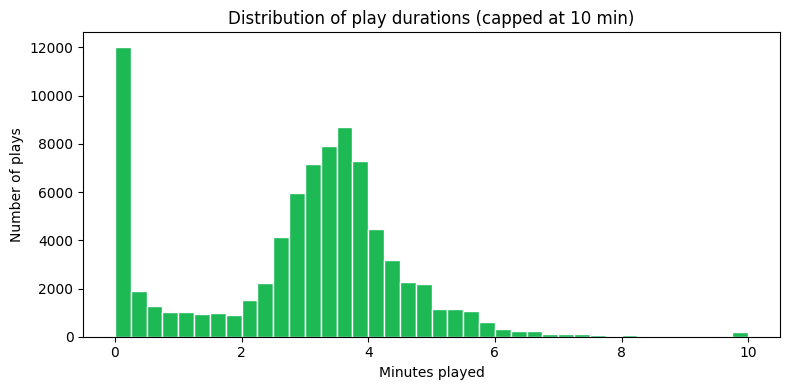

In [24]:
plt.figure(figsize=(8,4))
plt.hist(df['minutes_played'].clip(upper=10), bins=40, color='#1DB954', edgecolor='white')
plt.title('Distribution of play durations (capped at 10 min)')
plt.xlabel('Minutes played')
plt.ylabel('Number of plays')
plt.tight_layout()
plt.savefig('play_distribution.png', dpi=150)
plt.show()

In [25]:
q1 = df['minutes_played'].quantile(0.25)
q3 = df['minutes_played'].quantile(0.75)
iqr = q3 - q1
print(f'Q1: {q1:.2f} min | Q3: {q3:.2f} min | IQR: {iqr:.2f} min')
outliers = df[df['minutes_played'] > q3 + 1.5*iqr]
print(f'Outlier plays: {len(outliers)}')

Q1: 2.13 min | Q3: 3.88 min | IQR: 1.74 min
Outlier plays: 1094


In [26]:
outliers.groupby(['artist','track']).agg({'minutes_played': 'mean'}).sort_values('minutes_played', ascending=False).head(10)


,,minutes_played
artist,track,
Sachet Tandon,The Ultimate New Year Anthem Non-Stop Mix,65.339733
Miss Pooja,Ek Onkar - Mool Mantra,39.990967
Anuradha Paudwal,Om Gan Ganpate Namo Namah,32.955483
Neeraj Shridhar,Bollywood Nonstop 2022,29.989817
Sounds of Isha,Maha Mrityunjaya Mantra,28.690833
Dr. Ananda Balayogi Bhavanani,108 Om Chants,23.703550
Anuradha Paudwal,Gayatri Mantra 108 Times,23.121377
Jaswant Singh,"Hare Rama Hare Krishna, Pt. 1",23.055233
Suresh Wadkar,Gayatri Mantra108 Jaap,21.577069


Most of the songs which are longer than 10 mins are Bhanjans, mantras or non-stop mix, which are all valid cases.

In [27]:
hourly = df.groupby('hour').size().reset_index(name='plays')
hourly

,hour,plays
0,0,2234
1,1,2209
2,2,1705
3,3,1258
4,4,970
5,5,837
6,6,979
7,7,1785
8,8,3733
9,9,4430


In [28]:
daily = df.groupby('day').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
daily

,0
day,
Monday,10460
Tuesday,11316
Wednesday,10677
Thursday,12294
Friday,11341
Saturday,14735
Sunday,12025


In [29]:
monthly = df.groupby('month').agg(
    plays=('track','count'),
    hours=('minutes_played', lambda x: x.sum()/60)
).reset_index()
print(monthly)

    month  plays       hours
0       1   8153  390.893221
1       2   5532  274.770916
2       3   7204  364.675851
3       4   8378  417.854836
4       5   6854  335.713526
5       6   5445  266.756686
6       7   6020  273.858510
7       8   5598  259.726079
8       9   6711  331.410614
9      10   6602  335.377519
10     11   7950  382.519269
11     12   8401  407.826727


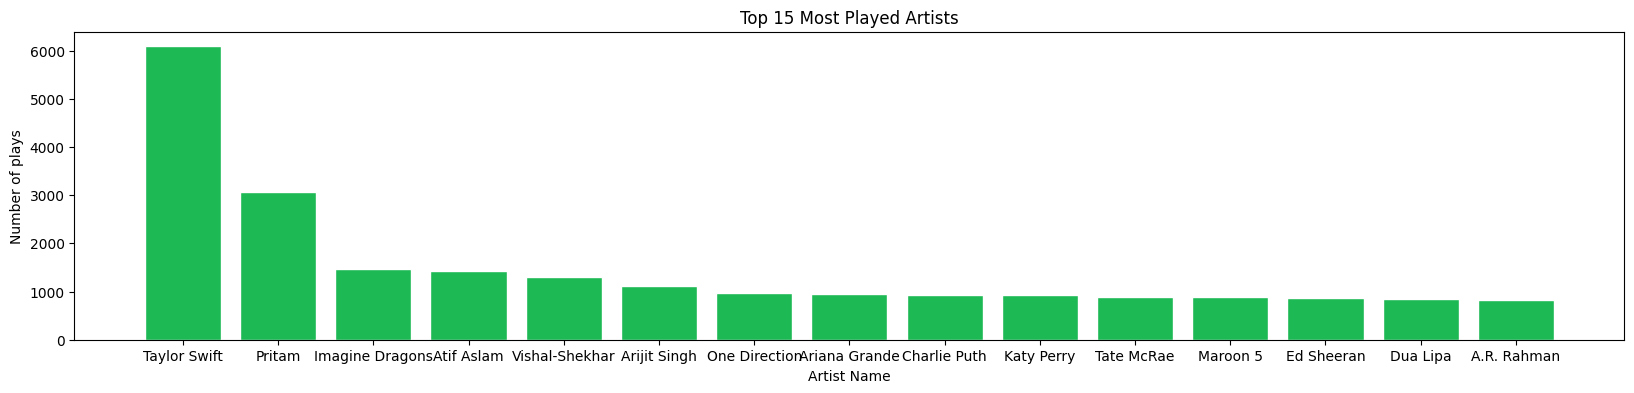

In [30]:
plt.figure(figsize=(20,4))
plt.bar(artist_stats['artist'], artist_stats['plays'],color='#1DB954', edgecolor='white')
plt.title('Top 15 Most Played Artists')
plt.xlabel('Artist Name')
plt.ylabel('Number of plays')
plt.savefig('top_15_artists.png', dpi=150)
plt.show()

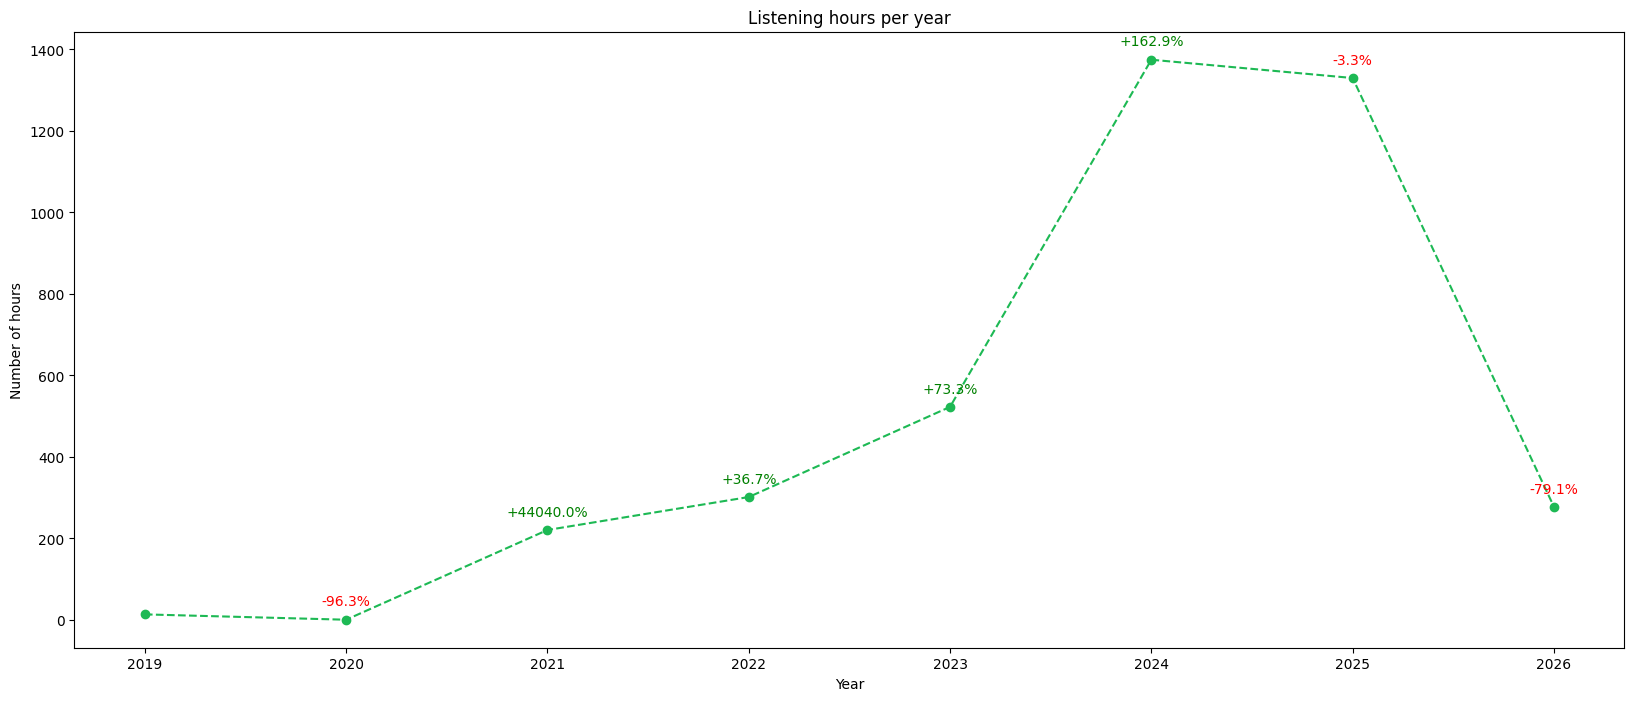

In [32]:
plt.figure(figsize=(20,8))
plt.plot(yearly['year'], yearly['hours'], color='#1DB954', marker='o', linestyle='--')
plt.title('Listening hours per year')
plt.xlabel('Year')
plt.ylabel('Number of hours')
for i in range(1, len(yearly)):
    label = f"{yearly['yoy_change'].iloc[i]:+.1f}%"
    plt.annotate(label,
                 xy=(yearly['year'].iloc[i], yearly['hours'].iloc[i]),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 color='green' if yearly['yoy_change'].iloc[i] > 0 else 'red')  # green if up, red if down
plt.savefig('yoy_change.png', dpi=150)
plt.show()

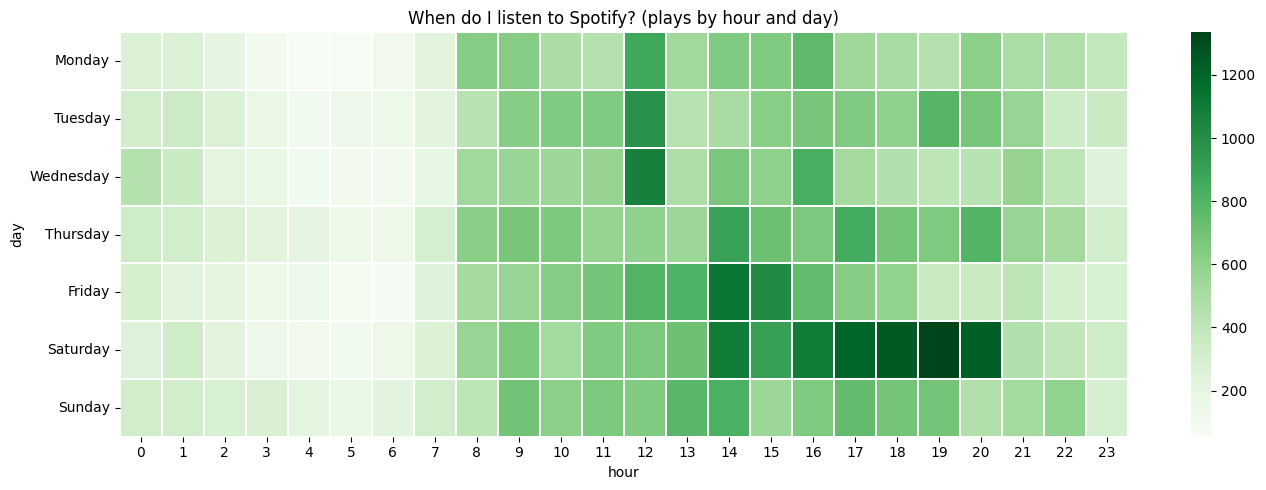

In [33]:
heatmap_data = df.groupby(['day','hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(14,5))
sns.heatmap(heatmap_data, cmap='Greens', linewidths=0.3)
plt.title('When do I listen to Spotify? (plays by hour and day)')
plt.tight_layout()
plt.savefig('listening_heatmap.png', dpi=150)
plt.show()


Most of the time I have listened to music from Monday to Wednesday at 12 pm is because I had French class and I have the habit of listening to songs when travelling in bus. Saturday has the most listens compared to other days because I work on Saturdays and I like to have a background music while working.